In [1]:
# Add project root (the folder that contains "src/") to sys.path
import sys
import time
from pathlib import Path

def add_project_root(marker_dir="src", max_hops=5):
    p = Path.cwd().resolve()
    for _ in range(max_hops):
        if (p / marker_dir).exists():
            sys.path.insert(0, str(p))
            print(f"[OK] Added to sys.path: {p}")
            return
        p = p.parent
    raise RuntimeError(f"Could not find '{marker_dir}' within {max_hops} parents from {Path.cwd()}")

add_project_root()  # looks for a "src" sibling/parent of the notebook


[OK] Added to sys.path: D:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation


In [2]:
import os, json, time, math, random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- your data utils ---
from src.data.prepare_dataset import (
    build_pairs_for_split,
    build_all_train_pairs,
    assert_dataset_layout,
    sanity_check_sample_alignment,
)
from src.data.dataloader import make_loaders
from src.data.augmentations import get_train_augs, get_val_augs


# --- your model pieces ---
from src.models.dpcn.dpcn_vat_exp1 import DPCN          # your DPCN (with threshold modes)
from src.models.blocks.cbam import CBAM               # your CBAM
from src.models.unet import UNet               # UNet that accepts in_channels (the variant we discussed)
from src.models.ablations.dpcn_cbam_unet import DPCN_CBAM_UNet  # the glue class we made earlier

# --- your evaluation & visualization ---
from src.evaluation.evaluate import evaluate_and_print
from src.evaluation.visualization import visualize_samples

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SAVE_DIR = Path("./runs/dpcn_cbam_unet")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
SEED = 1337
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
torch.backends.cudnn.benchmark = True


In [3]:
DRIVE_ROOT = "../data/raw/DRIVE"
assert_dataset_layout(DRIVE_ROOT, split="training", label_folder="1st_manual")
train_pairs = build_pairs_for_split(DRIVE_ROOT, split="training", label_folder="1st_manual")
val_pairs   = build_pairs_for_split(DRIVE_ROOT, split="test",     label_folder="1st_manual")

print("sample alignment:", sanity_check_sample_alignment(train_pairs, k=3))

sample alignment: [('21_training.png', '21_manual1.png'), ('22_training.png', '22_manual1.png'), ('23_training.png', '23_manual1.png')]


In [ ]:
RAW_ROOT = "../data/raw"
train_pairs = build_pairs_for_split(f"{RAW_ROOT}/DRIVE", split="training", label_folder="1st_manual")
val_pairs   = build_pairs_for_split(f"{RAW_ROOT}/DRIVE", split="test",     label_folder="1st_manual")

print("train sample alignment:", sanity_check_sample_alignment(train_pairs, k=3))
print("val   sample alignment:", sanity_check_sample_alignment(val_pairs,   k=3))

train sample alignment: [('21_training.png', '21_manual1.png'), ('22_training.png', '22_manual1.png'), ('23_training.png', '23_manual1.png')]
val   sample alignment: [('01_test.png', '01_manual1.png'), ('02_test.png', '02_manual1.png'), ('03_test.png', '03_manual1.png')]


In [5]:
train_loader, val_loader = make_loaders(
    train_pairs=train_pairs,
    val_pairs=val_pairs,
    image_size=512,
    batch_size=4,
    num_workers=0, # to change to  4
    seed=SEED,
    strict_fov=True,
    augs_train = None,#get_train_augs(512),
    augs_val = None #get_val_augs(512)
)

In [6]:
# DPCN core
dpcn = DPCN(
    in_ch=1,
    channels=64,    # 64       
    iters=5,             
    beta_init=0.3,
    aE=0.8,
    V_E=0.3,
    threshold_mode="paper_mod",   # start stable; later you can switch to "vat"/"scaled_vat"
    clamp_each_iter=False
)

# Full pipeline: DPCN -> concat(T*C) -> CBAM -> UNet(in_channels=T*C)
model_core = DPCN_CBAM_UNet(
    dpcn=dpcn,
    reduction_ratio=8,
    use_spatial_cbam=True
).to(DEVICE)

In [7]:
class LogitsOnly(nn.Module):
    """Wraps a (logits, ys, feats) model to expose logits-only forward(x[,fov])."""
    def __init__(self, core):
        super().__init__()
        self.core = core
    def forward(self, x):
        logits, _, _ = self.core(x)  # NOTE: no fov in eval/viz wrapper
        return logits

model_for_eval = LogitsOnly(model_core).to(DEVICE)

In [8]:
from src.training.loss_functions import DiceBCEComplementLoss
import torch

# (optional) estimate class weights from a few batches to handle heavy imbalance
def estimate_class_weights(loader, max_batches=20):
    with torch.no_grad():
        s = 0.0; n = 0
        for i, b in enumerate(loader):
            s += b["mask"].float().mean().item()  # foreground fraction in [0,1]
            n += 1
            if i+1 >= max_batches: break
    p = max(1e-6, min(1-1e-6, s / max(1, n)))      # foreground prior
    w1 = 1.0 / p                                    # weight FG inversely to its freq
    w0 = 1.0 / (1.0 - p)                            # weight BG inversely to its freq
    # normalize so w0 + w1 ≈ 2 (keeps scale stable)
    s2 = w0 + w1
    w0 = 2.0 * w0 / s2; w1 = 2.0 * w1 / s2
    return w0, w1, p

w0, w1, p = estimate_class_weights(train_loader, max_batches=20)
print(f"~ foreground prior p ≈ {p:.5f} | class weights -> w0={w0:.3f}, w1={w1:.3f}")

loss_fn = DiceBCEComplementLoss(
    w0=w0, w1=w1,
    dice_weight=0.5,         # tune if you like (e.g., 0.6 Dice / 0.4 BCE)
    bce_weight=0.5,
    exact_equation=False,    # keep False so the BCE term is minimized (not added)
    reduction="mean",
)

~ foreground prior p ≈ 0.07642 | class weights -> w0=0.153, w1=1.847


In [9]:
def train_one_epoch(model_core, loader, optimizer, scaler):
    model_core.train()
    total = 0.0
    for batch in loader:
        x   = batch["image"].to(DEVICE)   # [B,1,H,W]
        y   = batch["mask"].to(DEVICE)    # [B,1,H,W]
        fov = batch["fov"].to(DEVICE)     # [B,1,H,W]

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
            logits, ys, feats = model_core(x, fov=fov)   # <- use FOV during training
            loss = loss_fn(logits, y)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model_core.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        total += loss.item() * x.size(0)

    return total / len(loader.dataset)

@torch.no_grad()
def validate_loss_only(model_core, loader):
    model_core.eval()
    total = 0.0
    for batch in loader:
        x = batch["image"].to(DEVICE)
        y = batch["mask"].to(DEVICE)
        logits, _, _ = model_core(x)      # no FOV path in val loss; inputs are FOV-clamped already
        total += loss_fn(logits, y).item() * x.size(0)
    return total / len(loader.dataset)


In [10]:
def train_one_epoch(model_core, loader, optimizer, scaler, loss_fn):
    model_core.train()
    total = 0.0
    n_pix = 0
    for batch in loader:
        x   = batch["image"].to(DEVICE, non_blocking=True)
        y   = batch["mask"].to(DEVICE,  non_blocking=True)
        fov = batch["fov"].to(DEVICE,   non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type="cuda", enabled=(DEVICE=="cuda")):
            out = model_core(x, fov=fov)           # your model returns logits or a tuple
            logits = out[0] if isinstance(out, (list, tuple)) else out
            loss = loss_fn(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total += loss.item() * x.size(0)
        n_pix += x.size(0)
    return total / max(1, n_pix)

@torch.no_grad()
def validate_loss_only(model_core, loader, loss_fn):
    model_core.eval()
    total = 0.0
    n_pix = 0
    for batch in loader:
        x   = batch["image"].to(DEVICE, non_blocking=True)
        y   = batch["mask"].to(DEVICE,  non_blocking=True)
        fov = batch["fov"].to(DEVICE,   non_blocking=True)

        with torch.amp.autocast(device_type="cuda", enabled=(DEVICE=="cuda")):
            out = model_core(x, fov=fov)
            logits = out[0] if isinstance(out, (list, tuple)) else out
            loss = loss_fn(logits, y)

        total += loss.item() * x.size(0)
        n_pix += x.size(0)
    return total / max(1, n_pix)


def gpu_info(prefix=""):
    if DEVICE == "cuda":
        torch.cuda.synchronize()
        mem_alloc = torch.cuda.memory_allocated() / 1024**2
        mem_rsrv  = torch.cuda.memory_reserved() / 1024**2
        print(f"{prefix} GPU mem: allocated={mem_alloc:.1f}MB reserved={mem_rsrv:.1f}MB")

In [11]:
import json, time, math
from torch.optim.lr_scheduler import LambdaLR

optimizer = torch.optim.AdamW(model_core.parameters(), lr=3e-4, weight_decay=1e-4)
scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE=="cuda"))


EPOCHS = 50

# 5-epoch warmup into cosine
warmup_epochs = 5
def lr_lambda(e):
    if e < warmup_epochs:
        return (e+1)/warmup_epochs
    # cosine over remaining epochs
    progress = (e - warmup_epochs) / max(1, EPOCHS - warmup_epochs)
    return 0.5*(1 + math.cos(math.pi*progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


warmup_epochs = 5
def lr_lambda(e):
    if e < warmup_epochs: return (e+1)/warmup_epochs
    progress = (e - warmup_epochs) / max(1, EPOCHS - warmup_epochs)
    return 0.5*(1 + math.cos(math.pi*progress))
scheduler = LambdaLR(optimizer, lr_lambda)

best_val = float("inf")



for epoch in range(1, EPOCHS+1):
    print(f"----- EPOCH {epoch} -----")
    if DEVICE=="cuda": torch.cuda.synchronize()
    t0 = time.time()

    tr_loss = train_one_epoch(model_core, train_loader, optimizer, scaler, loss_fn)
    val_loss = validate_loss_only(model_core, val_loader, loss_fn)
    scheduler.step()

    if DEVICE=="cuda": torch.cuda.synchronize()
    print(f"[{epoch:03d}] train={tr_loss:.4f} val={val_loss:.4f} "
          f"lr={optimizer.param_groups[0]['lr']:.3e} time={(time.time()-t0):.1f}s")

    torch.save(model_core.state_dict(), SAVE_DIR / "last.pth")
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model_core.state_dict(), SAVE_DIR / "best.pth")
        with open(SAVE_DIR / "best.json","w") as f:
            json.dump({"epoch": epoch, "val_loss": val_loss}, f, indent=2)

----- EPOCH 1 -----
[001] train=1.3661 val=1.5120 lr=1.200e-04 time=2205.5s
----- EPOCH 2 -----
[002] train=1.1768 val=1.4411 lr=1.800e-04 time=492.9s
----- EPOCH 3 -----
[003] train=1.0813 val=1.3045 lr=2.400e-04 time=491.8s
----- EPOCH 4 -----
[004] train=1.0266 val=1.2160 lr=3.000e-04 time=487.6s
----- EPOCH 5 -----
[005] train=0.9891 val=1.1631 lr=3.000e-04 time=486.7s
----- EPOCH 6 -----


MemoryError: Unable to allocate 337. MiB for an array with shape (5043, 5837, 3) and data type float32

In [17]:
# load best
model_core.load_state_dict(torch.load(SAVE_DIR / "best.pth", map_location=DEVICE))
model_for_eval = LogitsOnly(model_core).to(DEVICE).eval()

# run your evaluation utility
evaluate_and_print(model_for_eval, test_dataloader=val_loader, device=DEVICE, threshold=0.5, compute_auc=True)

=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Dice           : 0.4141
IoU            : 0.2642
Sensitivity    : 0.3162
Specificity    : 0.9826
Precision      : 0.6411
FPR            : 0.0174
FDR            : 0.3589
Accuracy       : 0.9264
clDice         : 0.3668
Dice_thin      : 0.1443
Dice_thick     : 0.3419
ROC_AUC        : 0.8545
PR_AUC         : 0.4991
-- Micro (pooled over all pixels) --
Precision      : 0.6293
Sensitivity    : 0.3181
Specificity    : 0.9827
F1/Dice        : 0.4226
IoU            : 0.2679
Accuracy       : 0.9264
FPR            : 0.0173
FDR            : 0.3707
ROC_AUC        : 0.8431
PR_AUC         : 0.4876


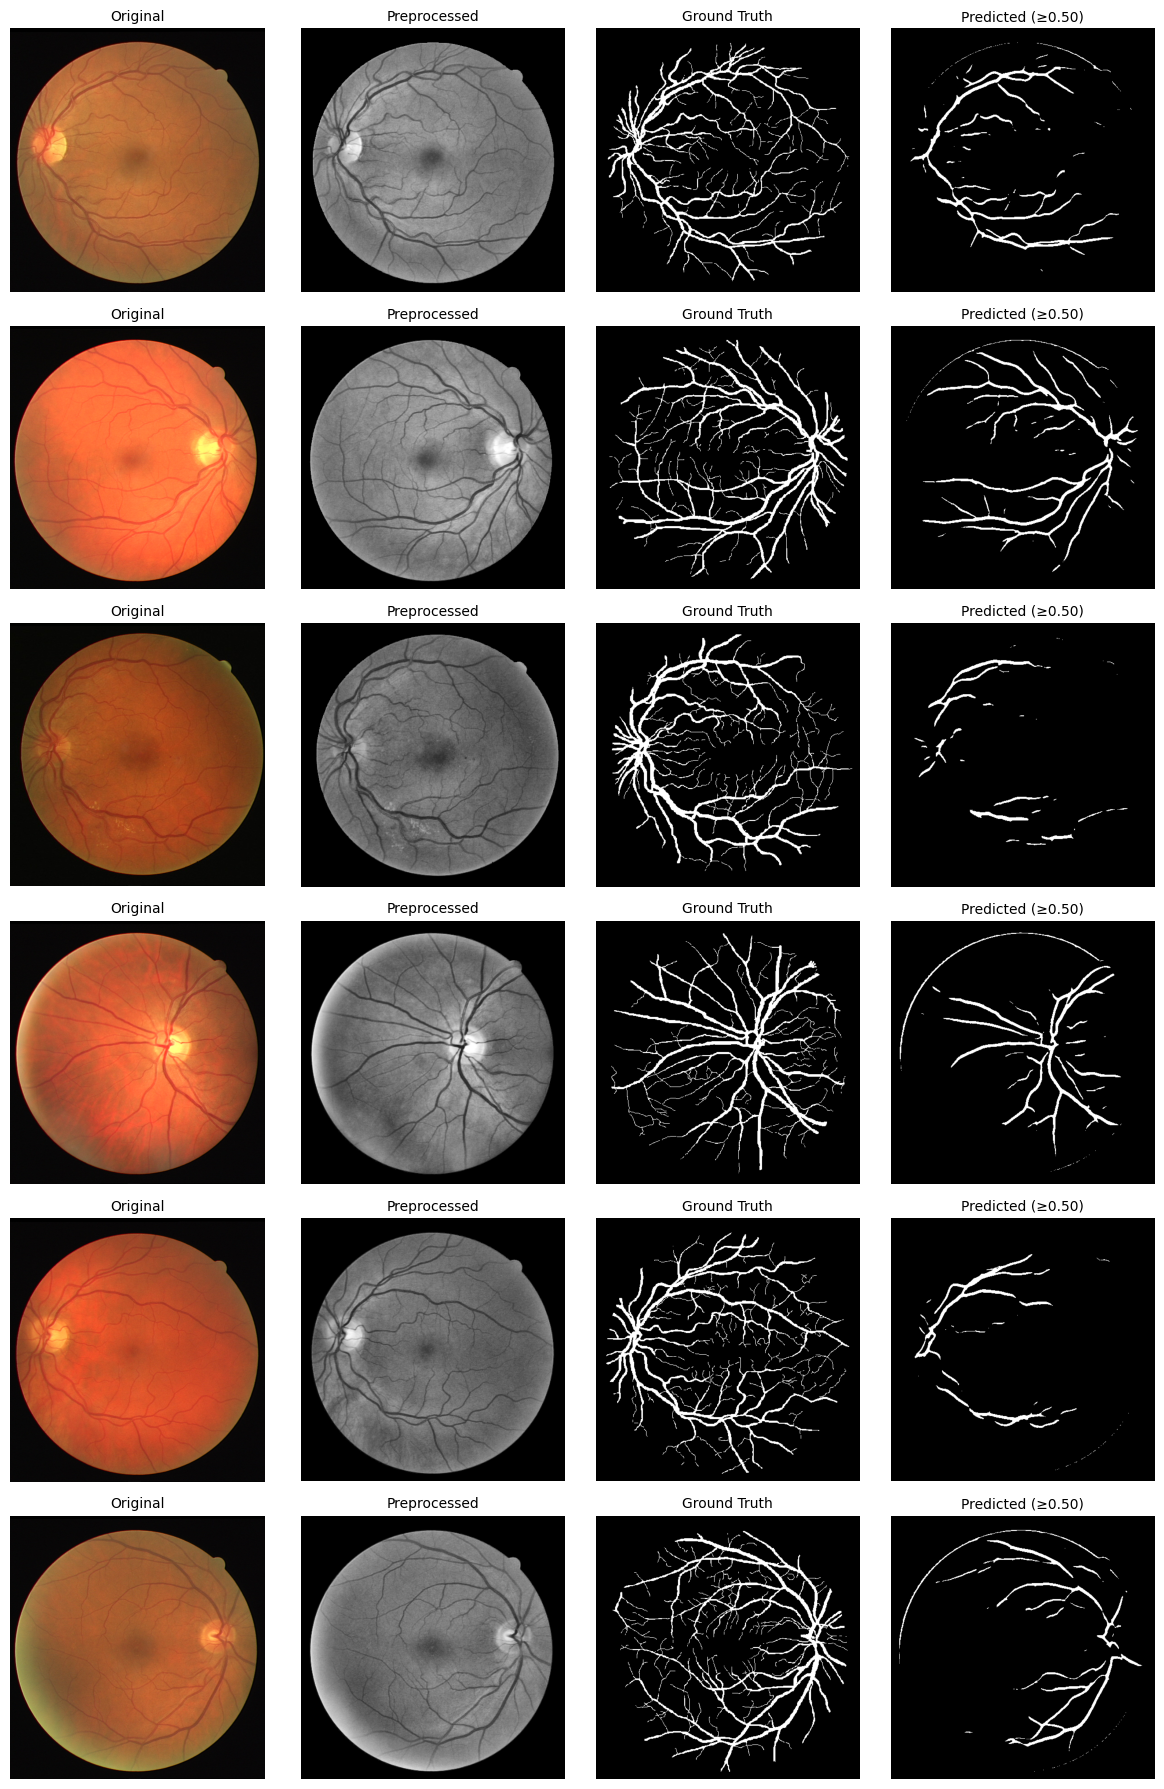

In [18]:
visualize_samples(
    model=model_for_eval,
    dataloader=val_loader,
    n_rows=6,
    device=DEVICE,
    threshold=0.5,
    clamp_pred_with_fov=True,
    figsize_per_row=(12, 3),
)